<a href="https://colab.research.google.com/github/OlenaBogoliubova/DATA-LOVE-ACADEMY/blob/main/HW_2_2_%D0%9B%D0%BE%D0%B3%D1%96%D1%81%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B7_scikit_learn_Bogoliubova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import joblib
from google.colab import drive
import os
from sklearn import metrics
from sklearn.metrics import auc
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score, f1_score)
import seaborn as sns
import joblib


In [2]:
drive.mount('/content/drive')
bank_df = pd.read_csv("drive/MyDrive/DATA LOVE/train.csv")
bank_df.head()


Mounted at /content/drive


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [3]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [4]:
train_df, val_df = train_test_split(bank_df, test_size=0.2, random_state=42, stratify=bank_df['Exited'])
print(f"Training data shape: {train_df.shape}")
print(f"Validation data shape: {val_df.shape}")

Training data shape: (12000, 14)
Validation data shape: (3000, 14)


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [5]:
input_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
target_col = 'Exited'

In [6]:
train_inputs = train_df[input_cols]
train_targets = train_df[target_col]
val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [7]:
numeric_cols = train_inputs.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()

In [8]:
numeric_cols, categorical_cols

(['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Geography', 'Gender'])

In [9]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,658.84,37.69,5.03,43008.17,1.59,0.79,0.49,117992.40
std,72.33,8.14,2.78,59906.63,0.53,0.41,0.50,45589.48
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83343.73
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123613.91
75%,708.00,42.00,7.00,109949.05,2.00,1.00,1.00,156912.81
max,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48


In [10]:
train_inputs[categorical_cols].nunique()

,0
Geography,3
Gender,2


In [11]:
numeric_cols = val_inputs.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = val_inputs.select_dtypes(include=['object']).columns.tolist()

In [ ]:
val_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,659.36,37.95,5.02,41616.26,1.59,0.78,0.48,116953.73
std,71.95,8.53,2.76,59001.35,0.53,0.41,0.50,46308.11
min,434.00,19.00,0.00,0.00,1.00,0.00,0.00,479.54
25%,604.00,32.00,3.00,0.00,1.00,1.00,0.00,82617.47
50%,663.00,37.00,5.00,0.00,2.00,1.00,0.00,122960.98
75%,708.00,42.00,7.00,107757.52,2.00,1.00,1.00,156687.36
max,850.00,72.00,10.00,185966.64,4.00,1.00,1.00,199953.33


In [12]:
val_inputs[categorical_cols].nunique()

,0
Geography,3
Gender,2


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [13]:
bank_df[numeric_cols].isna().sum()

,0
CreditScore,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [14]:
bank_df[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,658.94,37.74,5.03,42729.79,1.59,0.79,0.49,117784.67
std,72.26,8.22,2.78,59727.31,0.53,0.41,0.50,45734.45
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83058.14
50%,662.00,37.00,5.00,0.00,2.00,1.00,0.00,123584.87
75%,708.00,42.00,7.00,109531.02,2.00,1.00,1.00,156884.70
max,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48


In [15]:
scaler = MinMaxScaler()

In [16]:
scaler.fit(train_inputs[numeric_cols])

MinMaxScaler()

In [17]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

/tmp/ipykernel_5818/190829563.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
/tmp/ipykernel_5818/190829563.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])


In [18]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,0.54,0.35,0.50,0.21,0.20,0.79,0.49,0.59
std,0.17,0.15,0.28,0.29,0.18,0.41,0.50,0.23
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.41,0.25,0.30,0.00,0.00,1.00,0.00,0.42
50%,0.55,0.34,0.50,0.00,0.33,1.00,0.00,0.62
75%,0.66,0.43,0.70,0.52,0.33,1.00,1.00,0.78
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [19]:
val_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,0.55,0.36,0.50,0.20,0.20,0.78,0.48,0.58
std,0.17,0.15,0.28,0.28,0.18,0.41,0.50,0.23
min,0.01,0.02,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.41,0.25,0.30,0.00,0.00,1.00,0.00,0.41
50%,0.55,0.34,0.50,0.00,0.33,1.00,0.00,0.61
75%,0.66,0.43,0.70,0.51,0.33,1.00,1.00,0.78
max,1.00,0.96,1.00,0.89,1.00,1.00,1.00,1.00


In [20]:
bank_df[categorical_cols].nunique()

,0
Geography,3
Gender,2


In [21]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [22]:
encoder.fit(train_inputs[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [23]:
encoder.categories_

[array(['France', 'Germany', 'Spain'], dtype=object),
 array(['Female', 'Male'], dtype=object)]

In [24]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)

['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


In [25]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

/tmp/ipykernel_5818/2473262212.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
/tmp/ipykernel_5818/2473262212.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
/tmp/ipykernel_5818/2473262212.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [26]:
pd.set_option('display.max_columns', None)

In [27]:
val_inputs

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
6490,0.675418,Germany,Male,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704,0.0,1.0,0.0,0.0,1.0
3646,0.386635,France,Male,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942,1.0,0.0,0.0,0.0,1.0
5306,0.715990,France,Female,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853,1.0,0.0,0.0,1.0,0.0
652,0.577566,France,Female,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109,1.0,0.0,0.0,1.0,0.0
2627,0.589499,Spain,Female,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10550,0.589499,France,Male,0.357143,0.4,0.000000,0.333333,1.0,0.0,0.667682,1.0,0.0,0.0,0.0,1.0
8866,0.768496,France,Male,0.642857,0.6,0.000000,0.000000,1.0,0.0,0.885353,1.0,0.0,0.0,0.0,1.0
3244,0.589499,Spain,Male,0.250000,0.5,0.000000,0.333333,1.0,0.0,0.883589,0.0,0.0,1.0,0.0,1.0
12441,0.699284,Spain,Male,0.267857,0.5,0.658646,0.000000,1.0,0.0,0.528593,0.0,0.0,1.0,0.0,1.0


In [28]:
display(train_inputs.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0,0.0,1.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0,1.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0,0.0,1.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0,0.0,1.0


In [29]:
display(val_inputs.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
6490,0.675418,Germany,Male,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704,0.0,1.0,0.0,0.0,1.0
3646,0.386635,France,Male,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942,1.0,0.0,0.0,0.0,1.0
5306,0.715990,France,Female,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853,1.0,0.0,0.0,1.0,0.0
652,0.577566,France,Female,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109,1.0,0.0,0.0,1.0,0.0
2627,0.589499,Spain,Female,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420,0.0,0.0,1.0,1.0,0.0


Спочатку ми перевірили всі числові ствпці на наявність відсутніх значень. Так як відсутні значення не виявлені, то ми можемо пропустити процес імпутації.

Масштабування числових ознак ми проводимо, щоб уникнути непропорційного впливу ознак на втрати моделі, так як числові стовпці в нашому наборі даних мають різні діапазони. Після масштабування всі значення лежать в діапазоні від 0 до 1.

Ми навчаємо модель на числових даних, тому потрібно перетворити категоріальні дані на числа за допомогою one-hot кодування для категоріальних стовпців.

One-hot кодування передбачає додавання нового бінарного (0/1) стовпця для кожної унікальної категорії категоріального стовпця. Енкодер створює список категорій для кожного з категоріальних стовпців у наборі даних та додає нві стовпці до всіх наборів.

Для виконання кодування використовується метод transform об'єкта encoder. При перевірці видно, що ці нові стовпці були додані до навчального та валідаційного наборів.



5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [30]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (12000, 15)
train_targets: (12000,)
val_inputs: (3000, 15)
val_targets: (3000,)


In [31]:
!pip install pyarrow --quiet

In [32]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')

In [33]:
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

In [34]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (12000, 15)
train_targets: (12000,)
val_inputs: (3000, 15)
val_targets: (3000,)


In [35]:
train_inputs = pd.read_parquet('train_inputs.parquet')
val_inputs = pd.read_parquet('val_inputs.parquet')

train_targets = pd.read_parquet('train_targets.parquet')[target_col]
val_targets = pd.read_parquet('val_targets.parquet')[target_col]

In [36]:
val_targets

,Exited
6490,1.0
3646,0.0
5306,0.0
652,0.0
2627,0.0
...,...
10550,0.0
8866,1.0
3244,0.0
12441,0.0


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [37]:
model = LogisticRegression(solver='liblinear')

In [38]:
model.fit(train_inputs[numeric_cols + encoded_cols], train_targets)

LogisticRegression(solver='liblinear')

In [39]:
print(numeric_cols + encoded_cols)

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


In [40]:
model.coef_.round(2)

array([[-0.87,  8.45, -0.08, -1.1 , -3.93, -0.19, -1.25,  0.19, -0.96,
         0.61, -1.05, -0.27, -1.13]])

In [41]:
print(model.coef_.tolist())

[[-0.8727057654948849, 8.451461197130401, -0.07507593826903385, -1.095227113484121, -3.934637049980205, -0.18752677354595151, -1.2534613460000872, 0.18932980315740233, -0.9601551360076453, 0.6079395180143473, -1.0533218301540488, -0.2721184810439519, -1.1334189671031802]]


In [42]:
print(model.intercept_)

[-1.40553745]


In [43]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

In [44]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, train_targets)

LogisticRegression(max_iter=1000, random_state=42)

In [45]:
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

In [46]:
print(f"Accuracy on train: {accuracy_score(train_targets, train_preds):.4f}")
print(f"Accuracy on val:   {accuracy_score(val_targets, val_preds):.4f}")

Accuracy on train: 0.8743
Accuracy on val:   0.8717


7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [47]:
train_proba = model.predict_proba(X_train)[:, 1]
val_proba   = model.predict_proba(X_val)[:, 1]

In [48]:
train_preds = (train_proba >= 0.5).astype(int)
val_preds   = (val_proba >= 0.5).astype(int)

In [49]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 87.43%


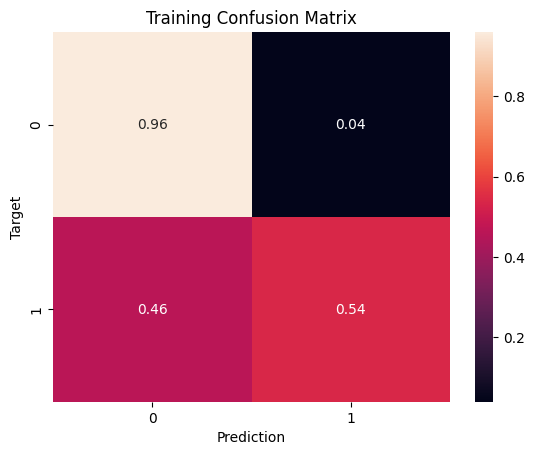

In [50]:
train_preds = predict_and_plot(X_train, train_targets, 'Training')

Accuracy: 87.17%


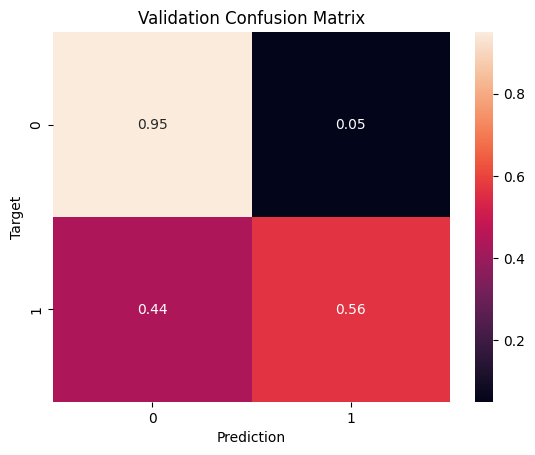

In [51]:
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

In [52]:
print(f"F1 Score Train: {f1_score(train_targets, train_preds):.4f}")
print(f"AUROC Train:    {roc_auc_score(train_targets, train_proba):.4f}")

print(f"F1 Score Val: {f1_score(val_targets, val_preds):.4f}")
print(f"AUROC Val:    {roc_auc_score(val_targets, val_proba):.4f}")

F1 Score Train: 0.6354
AUROC Train:    0.8824
F1 Score Val: 0.6412
AUROC Val:    0.8797


In [64]:
def compute_auroc_and_build_roc(inputs, targets, name=''):

  y_pred_proba = model.predict_proba(inputs)[:, 1]

  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

  roc_auc = metrics.auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.4f}')

  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.8824


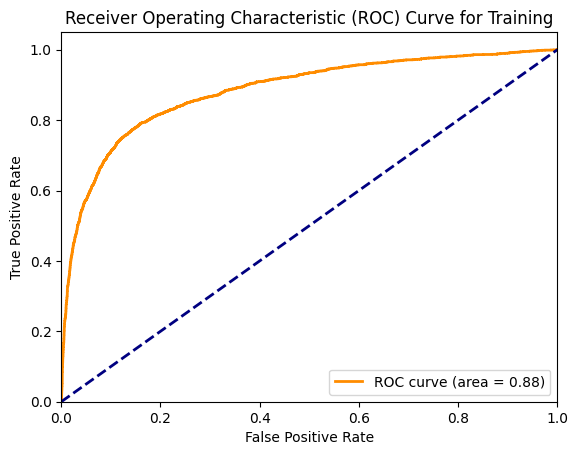

AUROC for Validation: 0.8797


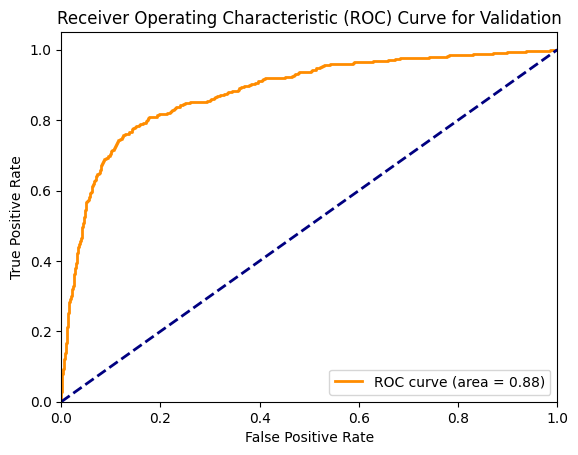

In [54]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

Модель навчилась непогано:

AUROC ~0.88 — це хороший результат, тобто модель значно краща за випадкове вгадування (0.5). Перенавчання відсутнє, Train і Val метрики майже однакові (різниця < 0.003).

F1 Score відносно невисокий (0.63). При AUROC 0.88 це говорить про те, що класи незбалансовані — модель гірше передбачає клас 1 (Exited = 1), бо таких клієнтів менше в датасеті. Поріг 0.5 може бути не оптимальним. Варто спробувати інші пороги (наприклад, 0.3 або 0.4), щоб підняти F1.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [55]:
majority_class = train_targets.value_counts().idxmax()
print(f"Majority class: {majority_class}")
print(f"Classes:\n{train_targets.value_counts()}")

Majority class: 0.0
Classes:
Exited
0.0    9558
1.0    2442
Name: count, dtype: int64


In [56]:
train_majority_preds = np.full(len(train_targets), majority_class)
val_majority_preds   = np.full(len(val_targets),   majority_class)

In [57]:
train_acc_majority = accuracy_score(train_targets, train_majority_preds)
val_acc_majority   = accuracy_score(val_targets,   val_majority_preds)

train_acc_lr = accuracy_score(train_targets, train_preds)
val_acc_lr   = accuracy_score(val_targets,   val_preds)

In [58]:
print(f"\n{'Model':<25} {'Train Accuracy':>15} {'Val Accuracy':>15}")
print("-" * 55)
print(f"{'Majority class':<25} {train_acc_majority:>15.4f} {val_acc_majority:>15.4f}")
print(f"{'Logistic Regression':<25} {train_acc_lr:>15.4f} {val_acc_lr:>15.4f}")


Model                      Train Accuracy    Val Accuracy
-------------------------------------------------------
Majority class                     0.7965          0.7967
Logistic Regression                0.8743          0.8717


Logistic Regression значно краща за baseline — на ~8% вище по accuracy і на train, і на val. Це говорить про те, що модель дійсно навчилась знаходити патерни в даних, а не просто вгадує мажоритарний клас.
Загальна оцінка — модель хороша:

Accuracy 87% виглядає добре, проте F1 лише 0.63 — це означає, що модель погано ловить клієнтів, які реально підуть (клас 1). Для бізнесу (відтік клієнтів) важливіше передбачити саме їх, тому F1 тут важливіша метрика ніж accuracy.

Підсумок: модель хороша як baseline — значно краща за наївний підхід, стабільна (без перенавчання), але має потенціал для покращення через балансування класів або складніші алгоритми.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [59]:
joblib.dump({
    'model':           model,
    'scaler':          scaler,
    'encoder':         encoder,
    'numeric_cols':    numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols':    encoded_cols
}, 'log_reg.joblib')

model_2 = joblib.load('log_reg.joblib')

print(f"Keys: {list(model_2.keys())}")

val_preds_2 = model_2['model'].predict(X_val)
print(f"Accuracy (original): {accuracy_score(val_targets, val_preds):.4f}")
print(f"Accuracy (model_2):  {accuracy_score(val_targets, val_preds_2):.4f}")

Keys: ['model', 'scaler', 'encoder', 'numeric_cols', 'categorical_cols', 'encoded_cols']
Accuracy (original): 0.8717
Accuracy (model_2):  0.8717


10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

def predict_bank_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [60]:
import warnings
warnings.filterwarnings("ignore")

def predict_bank_df(input_df: pd.DataFrame):
    scaler          = model_2['scaler']
    model           = model_2['model']
    encoder         = model_2['encoder']
    numeric_cols    = model_2['numeric_cols']
    categorical_cols = model_2['categorical_cols']
    encoded_cols    = model_2['encoded_cols']

    df = input_df.copy()

    df[numeric_cols] = scaler.transform(df[numeric_cols])

    df[encoded_cols] = encoder.transform(df[categorical_cols])

    X_input = df[numeric_cols + encoded_cols]

    prob = model.predict_proba(X_input)[:, 1]
    return prob

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [61]:
test_bank_df = pd.read_csv('drive/MyDrive/DATA LOVE/test.csv')

12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [63]:
sample_submission = pd.read_csv('drive/MyDrive/DATA LOVE/sample_submission.csv')
print("Sample submission:")
print(sample_submission.head())

probs = predict_bank_df(test_bank_df)

preds_df = pd.DataFrame({
    'id': test_bank_df['id'],
    'Exited': probs
})

sample_submission = sample_submission.drop(columns=['Exited']).merge(preds_df, on='id', how='left')

print(sample_submission.head())

sample_submission.to_csv('submission_log_reg.csv', index=False)
print("\nSaved: submission_log_reg.csv")

import shutil
shutil.copy('submission_log_reg.csv', '/content/drive/MyDrive/submission_log_reg.csv')
print("Saved on Google Drive!")

Sample submission:
      id  Exited
0  15000     0.5
1  15001     0.5
2  15002     0.5
3  15003     0.5
4  15004     0.5
      id    Exited
0  15000  0.074951
1  15001  0.035156
2  15002  0.153656
3  15003  0.195184
4  15004  0.055513

Saved: submission_log_reg.csv
Saved on Google Drive!
